# Model keypoint predictions

Load a trained run checkpoint and render random HE/IHC tile pairs with inferred keypoints.

Inference uses `SuperPoint.forward(training=False)`: NMS (`nms_radius=4`), border removal, then threshold filter (default **0.015**, same as `compare_base_detectors.ipynb`). Cross-stain KPIs are computed separately on these rendered keypoints (not training logits).

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.append(str(Path.cwd().parent.parent))
sys.path.append(str(Path.cwd().parent))

from dataset import StainPairKeypointDataset
from evaluation.kpis import match_keypoints_cross_stain, match_keypoints_to_gt
from explore_dataset import render_stain_pair_grid
from model_instance import ModelInstance, TrainingConfig, latest_checkpoint_path, load_existing_run
from training import build_model

In [ ]:
RUN_NAME = "smoke"
N_SAMPLES = 8
SEED = 0
THRESHOLD = 0.010
NCOLS = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
def resolve_run_weights(run_name):
    instance = ModelInstance(name=run_name, config=TrainingConfig(name=run_name))
    load_existing_run(instance)
    if instance.log_path.exists():
        saved = ModelInstance.load_log(instance.log_path)
        instance.config = saved.config
    latest = latest_checkpoint_path(instance.run_dir, run_name)
    if latest is not None:
        instance.last_pth_path = latest
        return latest, instance
    return Path(instance.config.weights_init), instance


def infer_keypoints(model, image, device):
    with torch.no_grad():
        out = model({"image": image.unsqueeze(0).to(device)}, training=False)
    kps = out["keypoints"][0].cpu().numpy()
    if len(kps) == 0:
        return None
    return kps


weights_path, run_instance = resolve_run_weights(RUN_NAME)
kp_radius = run_instance.config.kp_radius
model = build_model(weights_path=weights_path, device=DEVICE)
model.conf.detection_threshold = THRESHOLD
model.eval()
print(f"weights:   {weights_path}")
print(f"device:    {DEVICE}")
print(f"kp_radius: {kp_radius}")

weights:   /home/alexander.hallmann/Desktop/medical-image-registration/introducing_superpoint/runs/smoke/smoke_14-06_09-20.pth
device:    cuda
kp_radius: 8


[33] pair=0 depth=3 x=6 y=3  he=1112 ihc=1067 cross_matched=786 repeatability=0.71  he_gt=32 ihc_gt=29
[82] pair=0 depth=4 x=9 y=3  he=1297 ihc=1048 cross_matched=816 repeatability=0.63  he_gt=40 ihc_gt=35
[151] pair=0 depth=4 x=9 y=9  he=1236 ihc=990 cross_matched=743 repeatability=0.60  he_gt=51 ihc_gt=46
[543] pair=0 depth=5 x=6 y=17  he=1176 ihc=1120 cross_matched=806 repeatability=0.69  he_gt=30 ihc_gt=26
[619] pair=0 depth=5 x=15 y=20  he=1203 ihc=1115 cross_matched=831 repeatability=0.69  he_gt=40 ihc_gt=37
[1028] pair=1 depth=5 x=9 y=9  he=1100 ihc=1133 cross_matched=768 repeatability=0.68  he_gt=38 ihc_gt=34
[1280] pair=2 depth=4 x=4 y=5  he=862 ihc=837 cross_matched=563 repeatability=0.65  he_gt=54 ihc_gt=47
[1709] pair=2 depth=5 x=15 y=19  he=1141 ihc=860 cross_matched=614 repeatability=0.54  he_gt=31 ihc_gt=22
mean repeatability: 0.648


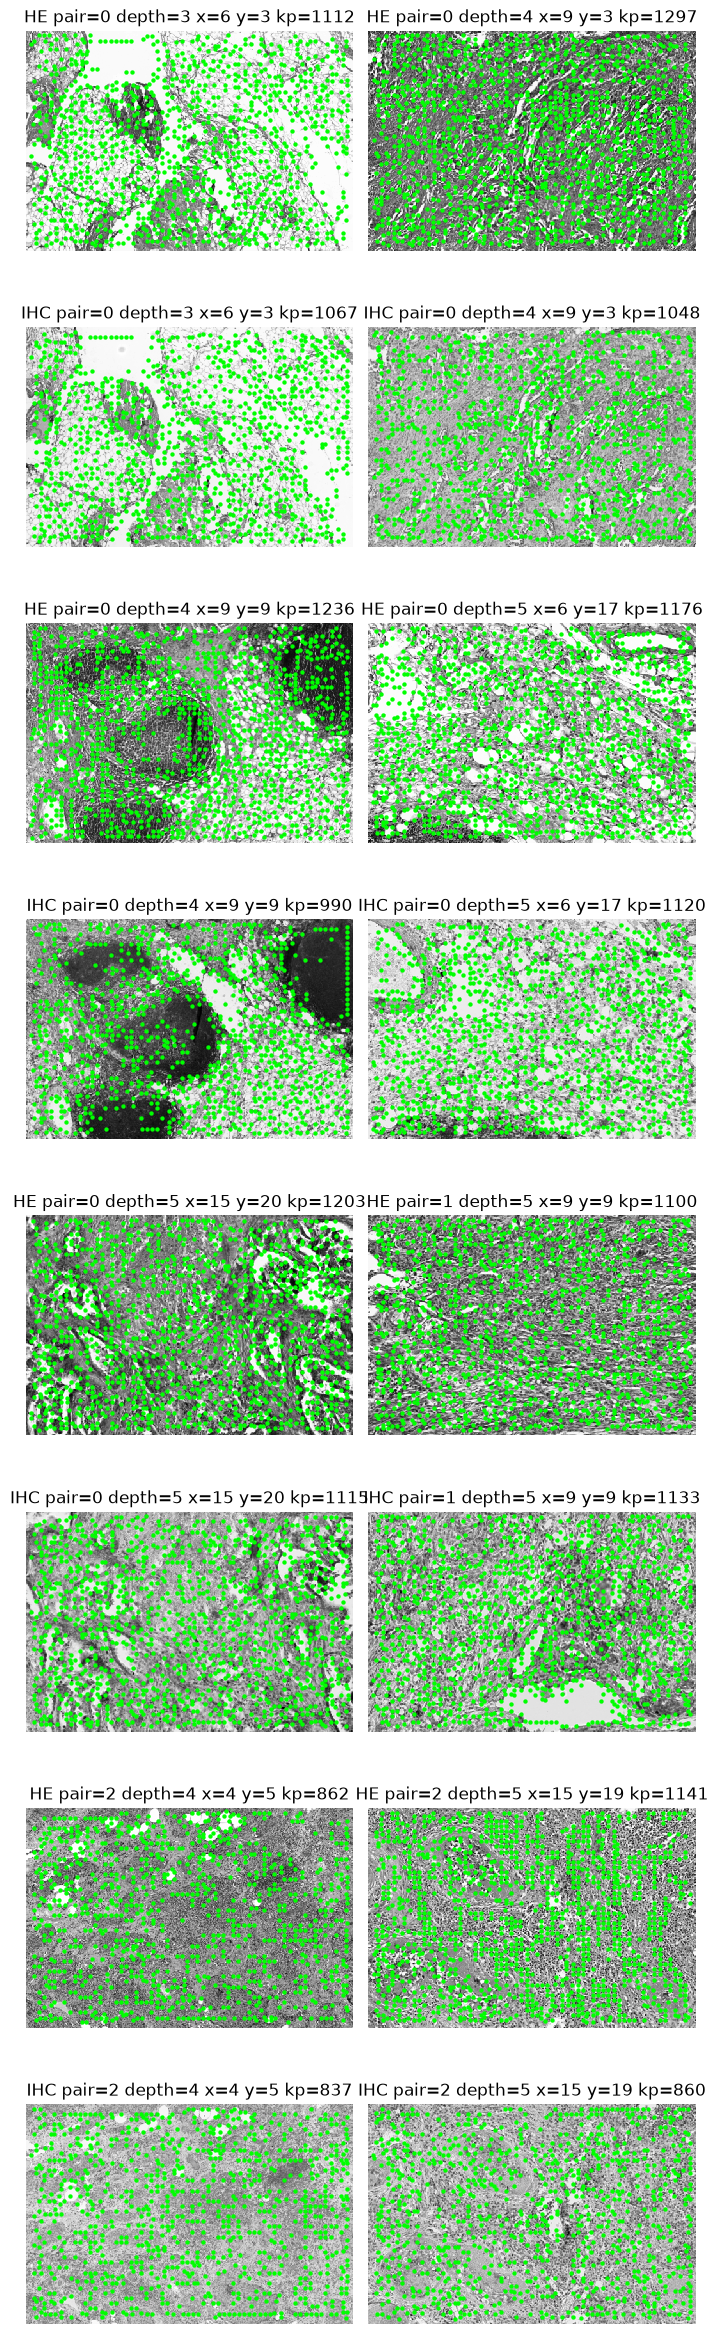

In [12]:
dataset = StainPairKeypointDataset()

rng = np.random.default_rng(SEED)
n_samples = min(N_SAMPLES, len(dataset))
indices = sorted(rng.choice(len(dataset), size=n_samples, replace=False).tolist())

def tile_key(meta):
    return meta["pair_id"], meta["crop_depth"], meta["x_idx"], meta["y_idx"]

kps_by_key = {}
repeatabilities = []
for idx in indices:
    item = dataset[idx]
    kps_he = infer_keypoints(model, item["image_he"], DEVICE)
    kps_ihc = infer_keypoints(model, item["image_ihc"], DEVICE)
    kps_by_key[tile_key(item["meta"])] = {"he": kps_he, "ihc": kps_ihc}

    cross = match_keypoints_cross_stain(kps_he, kps_ihc, kp_radius)
    repeatabilities.append(cross["repeatability"])
    gt = item["gt_keypoints"]
    n_he_gt = match_keypoints_to_gt(kps_he, gt, kp_radius) if gt is not None and gt.numel() > 0 else 0
    n_ihc_gt = match_keypoints_to_gt(kps_ihc, gt, kp_radius) if gt is not None and gt.numel() > 0 else 0
    meta = item["meta"]
    print(
        f"[{idx}] pair={meta['pair_id']} depth={meta['crop_depth']} "
        f"x={meta['x_idx']} y={meta['y_idx']}  "
        f"he={cross['n_he']} ihc={cross['n_ihc']} cross_matched={cross['n_matched']} "
        f"repeatability={cross['repeatability']:.2f}  "
        f"he_gt={n_he_gt} ihc_gt={n_ihc_gt}"
    )

print(f"mean repeatability: {np.mean(repeatabilities):.3f}")

def points_for_side(item, side):
    return kps_by_key[tile_key(item["meta"])][side]

fig = render_stain_pair_grid(dataset, indices, points_for_side, ncols=NCOLS)
plt.show()